In [173]:
#Import Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [174]:
#Read dataset
df=pd.read_csv("laptop_battery_health_usage.csv")
df.head()

,device_id,brand,model_year,os,usage_type,daily_usage_hours,charging_cycles,avg_charge_limit_percent,battery_health_percent,battery_age_months,overheating_issues,performance_rating
0,LB001,HP,2021,Windows,Office,6,420,90,86,36,No,4
1,LB002,Dell,2020,Windows,Programming,8,610,100,78,48,Yes,3
2,LB003,Apple,2022,macOS,Creative,7,310,85,92,24,No,5
3,LB004,Lenovo,2019,Windows,Student,5,700,100,70,60,Yes,3
4,LB005,Asus,2021,Windows,Gaming,9,820,100,65,40,Yes,2


In [175]:
df.rename(columns={'os': 'operation system '}, inplace=True)

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   device_id                 50 non-null     object
 1   brand                     50 non-null     object
 2   model_year                50 non-null     int64 
 3   operation system          50 non-null     object
 4   usage_type                50 non-null     object
 5   daily_usage_hours         50 non-null     int64 
 6   charging_cycles           50 non-null     int64 
 7   avg_charge_limit_percent  50 non-null     int64 
 8   battery_health_percent    50 non-null     int64 
 9   battery_age_months        50 non-null     int64 
 10  overheating_issues        50 non-null     object
 11  performance_rating        50 non-null     int64 
dtypes: int64(7), object(5)
memory usage: 4.8+ KB


In [177]:
# check Missing value
df.isnull().sum()

,0
device_id,0
brand,0
model_year,0
operation system,0
usage_type,0
daily_usage_hours,0
charging_cycles,0
avg_charge_limit_percent,0
battery_health_percent,0
battery_age_months,0


In [178]:
# Check Duplication
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   device_id                 50 non-null     object
 1   brand                     50 non-null     object
 2   model_year                50 non-null     int64 
 3   operation system          50 non-null     object
 4   usage_type                50 non-null     object
 5   daily_usage_hours         50 non-null     int64 
 6   charging_cycles           50 non-null     int64 
 7   avg_charge_limit_percent  50 non-null     int64 
 8   battery_health_percent    50 non-null     int64 
 9   battery_age_months        50 non-null     int64 
 10  overheating_issues        50 non-null     object
 11  performance_rating        50 non-null     int64 
dtypes: int64(7), object(5)
memory usage: 4.8+ KB


In [179]:
#Display descriptive statistics for
df.describe()

,model_year,daily_usage_hours,charging_cycles,avg_charge_limit_percent,battery_health_percent,battery_age_months,performance_rating
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000
mean,2020.560000,6.600000,526.400000,92.100000,80.16000,42.240000,3.580000
std,1.567007,1.498298,220.405563,6.857887,11.83278,18.118161,1.144463
min,2018.000000,4.000000,180.000000,80.000000,55.00000,12.000000,1.000000
25%,2019.250000,6.000000,342.500000,85.000000,72.50000,25.500000,3.000000
50%,2021.000000,6.000000,495.000000,90.000000,82.50000,38.000000,4.000000
75%,2022.000000,8.000000,695.000000,100.000000,90.00000,58.500000,4.750000
max,2023.000000,10.000000,950.000000,100.000000,98.00000,72.000000,5.000000


In [180]:
# Check Duplication
df.duplicated().sum()

np.int64(0)

In [181]:
categorical_columns = ['model_year', 'daily_usage_hours','charging_cycles',
                      'avg_charge_limit_percent', 'battery_health_percent',
                      'battery_age_months', 'performance_rating']
for col in categorical_columns:
    print(f"Category in {col} is : {df[col].unique()}")

Category in model_year is : [2021 2020 2022 2019 2023 2018]
Category in daily_usage_hours is : [ 6  8  7  5  9  4 10]
Category in charging_cycles is : [420 610 310 700 820 540 210 880 350 480 900 620 400 300 850 220 450 560
 680 490 600 520 180 570 730 460 950 320 500 430 780 410 260 870 330 640
 190 760 340 470 710 380 200]
Category in avg_charge_limit_percent is : [ 90 100  85  95  80]
Category in battery_health_percent is : [86 78 92 70 65 80 95 60 88 83 58 75 90 91 62 94 85 79 82 89 81 76 74 59
 97 77 68 84 55 87 96 72 66 93 61 63 69 98]
Category in battery_age_months is : [36 48 24 60 40 50 18 72 30 54 42 12]
Category in performance_rating is : [4 3 5 2 1]


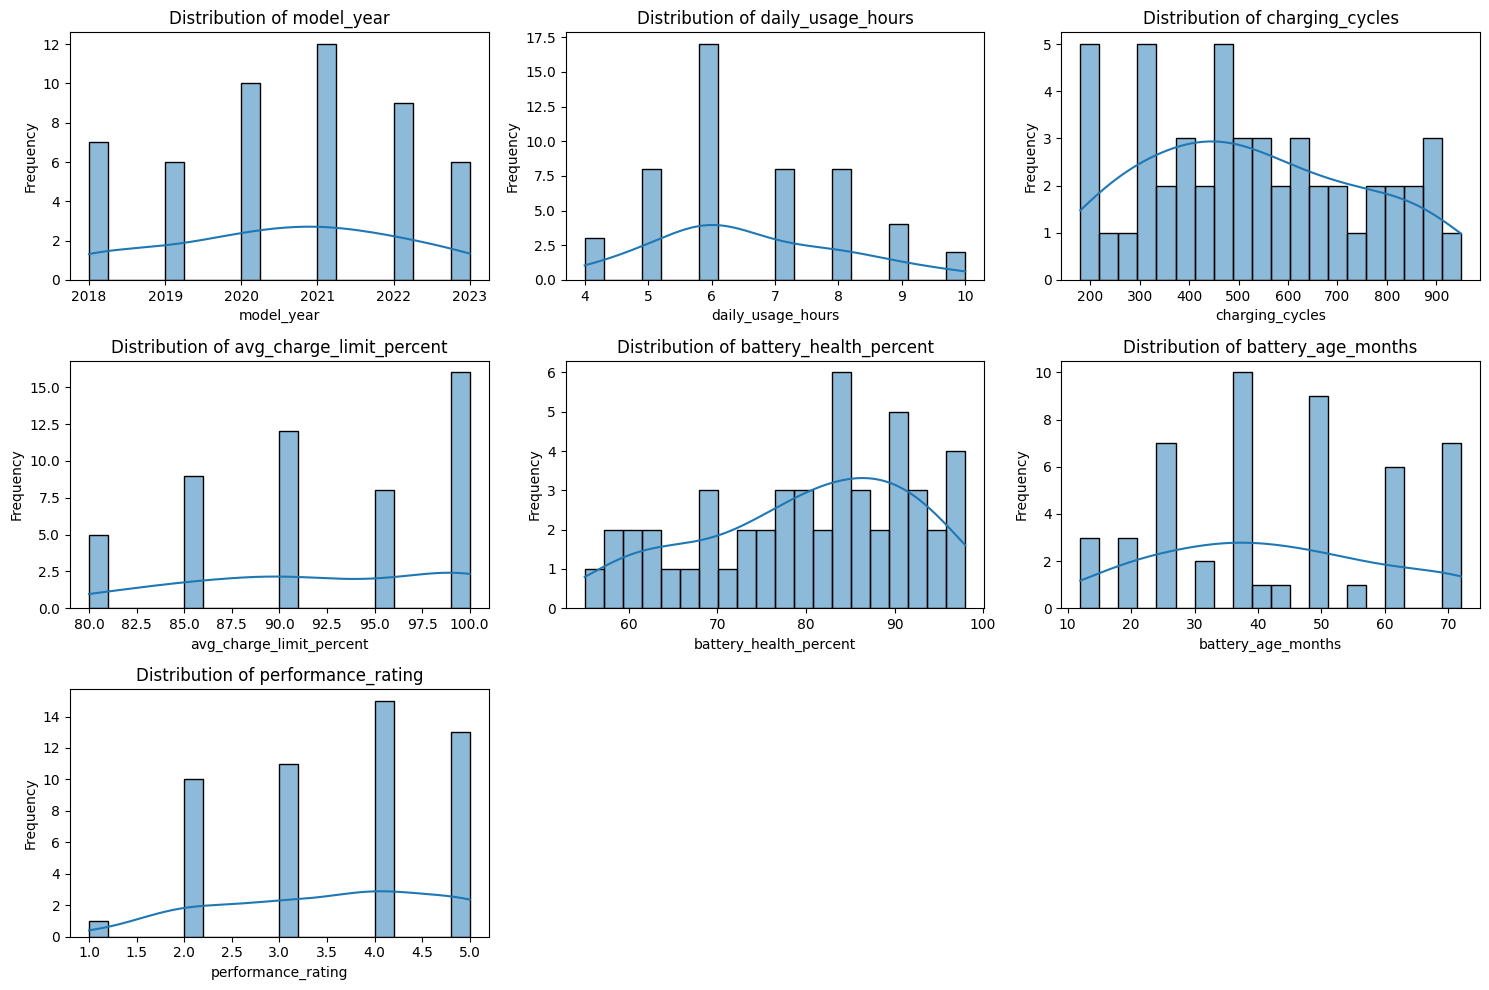

In [182]:
numerical_features = ['model_year', 'daily_usage_hours', 'charging_cycles',
                      'avg_charge_limit_percent', 'battery_health_percent',
                      'battery_age_months', 'performance_rating']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(data=df[feature], bins=20, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation Analysis of Numerical Features

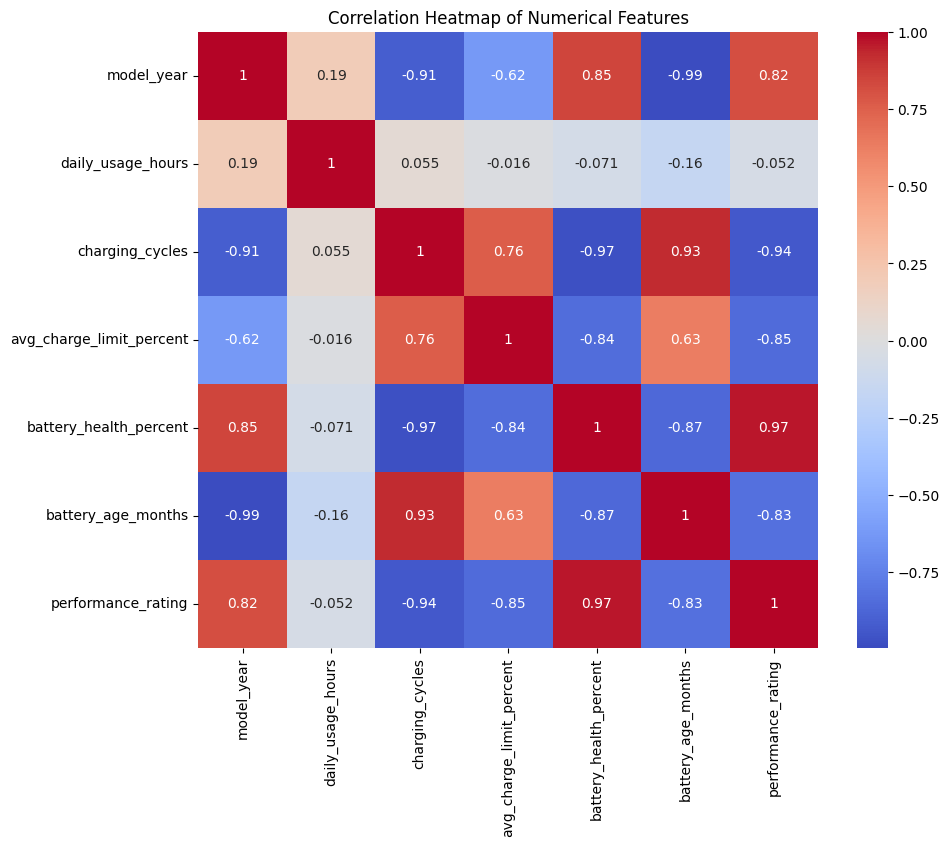

In [183]:
numerical_features = ['model_year', 'daily_usage_hours', 'charging_cycles',
                      'avg_charge_limit_percent', 'battery_health_percent',
                      'battery_age_months', 'performance_rating']

correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Relationship between Average Charge Limit Percent and Performance Rating

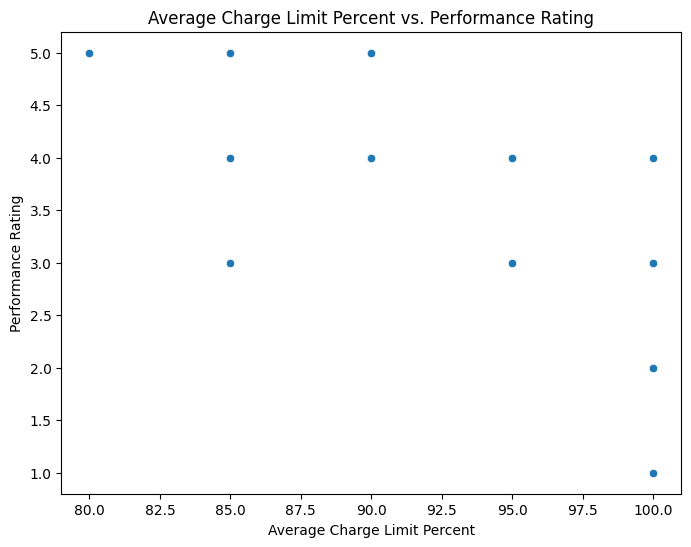

In [184]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='avg_charge_limit_percent', y='performance_rating', data=df)
plt.title('Average Charge Limit Percent vs. Performance Rating')
plt.xlabel('Average Charge Limit Percent')
plt.ylabel('Performance Rating')
plt.show()

### Relationship between Charging Cycles and Battery Health

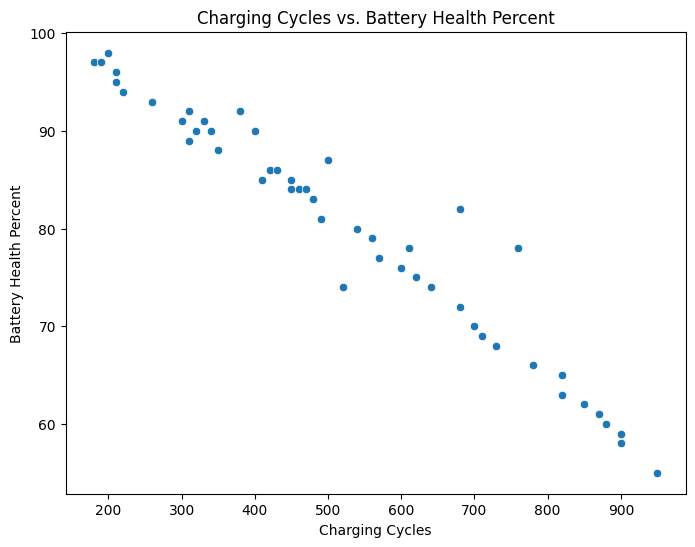

In [185]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='charging_cycles', y='battery_health_percent', data=df)
plt.title('Charging Cycles vs. Battery Health Percent')
plt.xlabel('Charging Cycles')
plt.ylabel('Battery Health Percent')
plt.show()

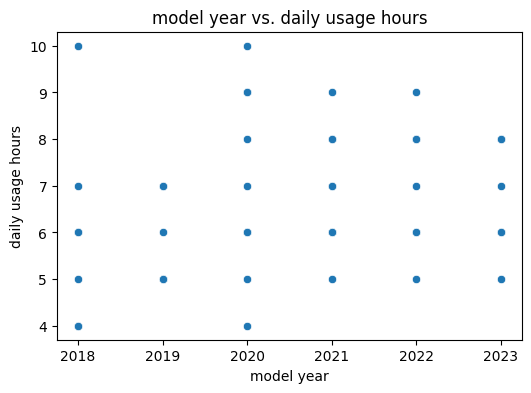

In [186]:
#Relationship between model_year  and daily_usage_hours
plt.figure(figsize=(6, 4))
sns.scatterplot(x='model_year', y='daily_usage_hours', data=df)
plt.title('model year vs. daily usage hours')
plt.xlabel('model year')
plt.ylabel('daily usage hours')
plt.show()

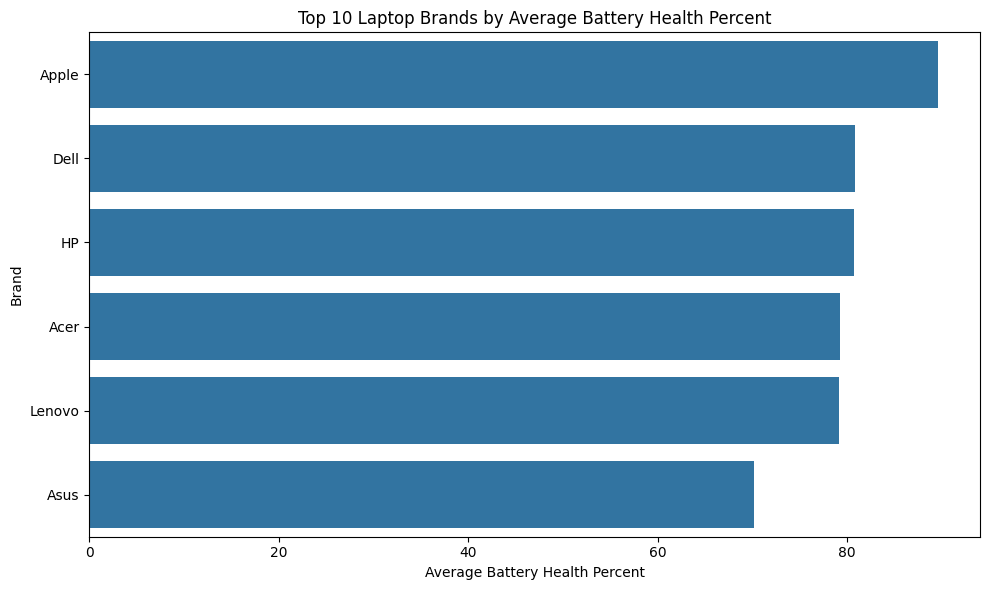

In [187]:
# Calculate average battery health for each brand
avg_health_by_brand = df.groupby('brand')['battery_health_percent'].mean().sort_values(ascending=False)

n = 10  # Limiting to top 10 brands for better visualization
top_brands = avg_health_by_brand.head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title(f'Top {n} Laptop Brands by Average Battery Health Percent')
plt.xlabel('Average Battery Health Percent')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

In [188]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# One-hot encode categorical features
categorical_cols_to_encode = ['brand', 'operation system ', 'usage_type', 'overheating_issues']
df_processed = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Create a new feature: laptop_age
df_processed['laptop_age'] = 2024 - df_processed['model_year']

# Remove 'model_year' column after using it to create 'laptop_age'
df_processed.drop('model_year', axis=1, inplace=True)

# Normalization of numerical features
scaler = MinMaxScaler()

# List of numerical features that need to be normalized
# 'device_id' is an identifier and should not be scaled or used in modeling directly
numerical_features_to_scale = [
    'daily_usage_hours',
    'charging_cycles',
    'avg_charge_limit_percent',
    'battery_health_percent',
    'battery_age_months',
    'laptop_age' # Include the newly created feature
]

# Applying the normalization process to selected numerical features
df_processed[numerical_features_to_scale] = scaler.fit_transform(df_processed[numerical_features_to_scale])

print("DataFrame after preprocessing:")
display(df_processed.head())

DataFrame after preprocessing:


,device_id,daily_usage_hours,charging_cycles,avg_charge_limit_percent,battery_health_percent,battery_age_months,performance_rating,brand_Apple,brand_Asus,brand_Dell,brand_HP,brand_Lenovo,operation system _macOS,usage_type_Gaming,usage_type_Office,usage_type_Programming,usage_type_Student,overheating_issues_Yes,laptop_age
0,LB001,0.333333,0.311688,0.50,0.720930,0.400000,4,False,False,False,True,False,False,False,True,False,False,False,0.4
1,LB002,0.666667,0.558442,1.00,0.534884,0.600000,3,False,False,True,False,False,False,False,False,True,False,True,0.6
2,LB003,0.500000,0.168831,0.25,0.860465,0.200000,5,True,False,False,False,False,True,False,False,False,False,False,0.2
3,LB004,0.166667,0.675325,1.00,0.348837,0.800000,3,False,False,False,False,True,False,False,False,False,True,True,0.8
4,LB005,0.833333,0.831169,1.00,0.232558,0.466667,2,False,True,False,False,False,False,True,False,False,False,True,0.4


### 1. Prepare Data for Classification

In [189]:
import pandas as pd

# Define features (X) and target (y)
# 'device_id' is an identifier and should be excluded from features
# 'battery_health_percent' is highly correlated with 'performance_rating' and might cause data leakage.
# We remove it from features to force the model to learn from other attributes.
X = df_processed.drop(columns=['device_id', 'performance_rating', 'battery_health_percent'])
# Ensure 'performance_rating' is treated as discrete integer classes (1-5)
y = df_processed['performance_rating'].astype(int)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display the first few rows of X and y
print("\nFeatures (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) shape: (50, 16)
Target (y) shape: (50,)

Features (X) head:


,daily_usage_hours,charging_cycles,avg_charge_limit_percent,battery_age_months,brand_Apple,brand_Asus,brand_Dell,brand_HP,brand_Lenovo,operation system _macOS,usage_type_Gaming,usage_type_Office,usage_type_Programming,usage_type_Student,overheating_issues_Yes,laptop_age
0,0.333333,0.311688,0.50,0.400000,False,False,False,True,False,False,False,True,False,False,False,0.4
1,0.666667,0.558442,1.00,0.600000,False,False,True,False,False,False,False,False,True,False,True,0.6
2,0.500000,0.168831,0.25,0.200000,True,False,False,False,False,True,False,False,False,False,False,0.2
3,0.166667,0.675325,1.00,0.800000,False,False,False,False,True,False,False,False,False,True,True,0.8
4,0.833333,0.831169,1.00,0.466667,False,True,False,False,False,False,True,False,False,False,True,0.4



Target (y) head:


,performance_rating
0,4
1,3
2,5
3,3
4,2


### 2. Split Data into Training and Testing Sets

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check the distribution of target variable in train and test sets
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in testing set:")
print(y_test.value_counts(normalize=True))

X_train shape: (40, 16)
X_test shape: (10, 16)
y_train shape: (40,)
y_test shape: (10,)

Target distribution in training set:
performance_rating
4    0.325
5    0.225
3    0.225
2    0.200
1    0.025
Name: proportion, dtype: float64

Target distribution in testing set:
performance_rating
5    0.4
4    0.2
2    0.2
3    0.2
Name: proportion, dtype: float64


### 3. Train a Classification Model (RandomForestClassifier)

In [191]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize the Random Forest Classifier
# We'll use a random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
# Ensure y_train is of integer type for classification
model.fit(X_train, y_train.astype(int))

print("RandomForestClassifier trained successfully!")

RandomForestClassifier trained successfully!


### 4. Evaluate the Model

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Confusion Matrix:


,1,2,3,4,5
1,0,0,0,0,0
2,0,2,0,0,0
3,0,0,2,0,0
4,0,0,0,2,0
5,0,0,0,0,4


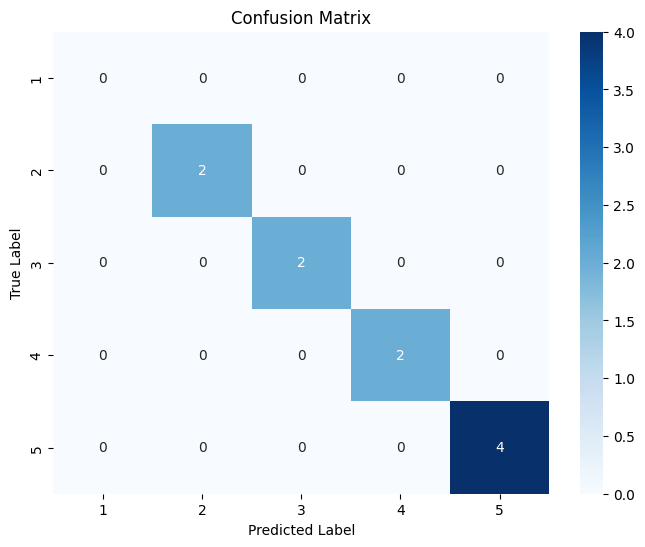

In [192]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model performance
accuracy = accuracy_score(y_test.astype(int), y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test.astype(int), y_pred))

print("\nConfusion Matrix:")
# Pass 'labels=model.classes_' to ensure the confusion matrix has dimensions for all classes
conf_matrix = confusion_matrix(y_test.astype(int), y_pred, labels=model.classes_)
display(pd.DataFrame(conf_matrix, index=model.classes_, columns=model.classes_))

# Plot Confusion Matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()